# Lorenz96
For a number of variables $ J \in \mathbb{N} $, external force $ F \in \mathbb{R} $ and state variable $ \mathbb{u} \in \mathbb{R}^J $ on 1D periodic domain, the Lorenz 96 equation (Lorenz 1996) is given by

$$ \frac {du^{i}}{dt} =(u^{i+1}-u^{i-2})u^{i-1}-u^{i}+F, $$

with $ u^{-1} = u^{J-1} $, $ u^0 = u^J $, and $ u^{J+1} = u^1 $.

## Partial observation
Let $ J = 3J' $ for $ J' \in \mathbb{N} $.

$$ P = [e_1, e_2, 0, e_4, e_5, 0, e_7, \dots, 0] \in \mathbb{R}^{J \times J}, $$

where $ (e_i)_{i=1}^J $ is a standard basis of $ \mathbb{R}^J $.

cf. K. J. H. Law, D. Sanz-Alonso, A. Shukla, and A. M. Stuart, Filter accuracy for the Lorenz 96 model: Fixed versus adaptive observation operators, Phys. Nonlinear Phenom., 325 (2016), pp. 1–13.

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from da.l96 import lorenz96
from da.scheme import rk4
from da.visualize import plot_loss
from da.etkf import ETKF
from da.po import PO
import visualize
plt.rcParams['text.usetex'] = False # 場当たり的な対応

data_dir = "data/20260410v5"

In [69]:
# ==========================================
# Parameter Configurations
# ==========================================
# System Parameters
J = 60          # dim of state space
F = 8           # forcing
dt = 0.01       # time step size
N0 = 20 * 360   # number of spin-up time steps
N = 20 * 50     # number of simulation time steps

# Observation Parameters
obs_per = 1     # observation interval in steps
r = 1.0         # observation noise std

# Data Assimilation Parameters
m = 10          # ensemble size
num_seeds = 20   # number of random seeds for simulation & plotting
seed_list = np.arange(num_seeds)
alpha_list = [0.0, 0.5, 2.0, 10.0, 100.0] # multiplicative inflation factors
methods = ["po_add", "po_proj"] # DA methods

# Visualization / Evaluation Parameters
method = "po_add"          # default DA method to plot
per_vis = 20               # plotting frequency
per_ticklabel = per_vis*20 # plot ticks parameter
N_end = 50                 # plot until N_end steps in SE plot
i_seed = 0                 # seed index for spatio-temporal plots
# i_alpha = 1                # alpha index for spatio-temporal plots
alpha_list_vis_st = [0.0, 0.5, 2.0] # alpha list for spatio-temporal plots (assert 'alpha_list_vis_st = alpha_list[:some_int]')
k_ens = 0                  # ensemble index for spatio-temporal plots
n_start = 0                # start step for spatio-temporal plots
n_end = N                  # end step for spatio-temporal plots


In [44]:
# Lorenz96
# J: dim of state space

# F: forcing

print("(J, F):", (J, F))

(J, F): (60, 8)


## Generate the true trajectory

In [45]:
# generate data
# dt: time step size

# N: number of time steps, 1 years : 20*360*1 steps

# initial state near the stationary point
x0 = F*np.ones(J) # the stationary point
x0[19] *= 1.001 # perturb

# use my modules
scheme = rk4
p = (F, )

try:
    x_true = np.load(f"{data_dir}/x_true_l96_full.npy")
    print("x_true loaded:", x_true.shape)
except:
    result = np.zeros((N0+N,len(x0)))
    x = x0
    result[0] = x[:]

    for n in range(1, N0+N):
        t = n*dt
        x = scheme(lorenz96, t, x, p, dt)
        result[n] = x[:]


    x_true = result[N0:] # spin up 1 year and save per 6 hours
    print(x_true.shape)
    np.save(f"{data_dir}/x_true_l96_full", x_true)

x_true loaded: (1000, 60)


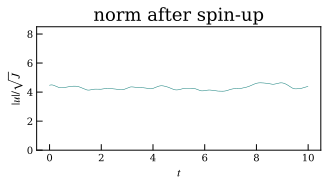

In [46]:
# norm (normalized energy)
norm = np.linalg.norm(x_true[:], axis=-1)/np.sqrt(J)
t = np.arange(N)*dt
fig3, ax3 = plt.subplots()
ax3.grid(False)
ax3.set_title('norm after spin-up')
ax3.set_xlabel('$t$')
ax3.set_ylabel('$ |u|/\\sqrt{J}$')
ax3.set_ylim([0.0, 8.5])
ax3.plot(t, norm, lw=0.5)
fig3.tight_layout()
# fig3.savefig(f"{data_dir}/l96_norm.pdf")

## DA setting

In [47]:
# observation interval
print("obs_per", obs_per, "steps")

# assimilation interval
Dt = dt * obs_per

# Model function for EnKF
def M(x, Dt):
    for i in range(obs_per):
        x = rk4(lorenz96, 0, x, p, dt)
    return x

# Observation operator
# H_diag = np.ones(J) # full

H_diag = np.ones(J) # partial 1
H_diag[2::3] = 0
H = np.diag(H_diag) # shape: (60, 60)
H = H[H_diag!=0] # shape: (40, 60)

Ny = np.linalg.matrix_rank(H)
print("H.shape:", H.shape)
print("diag of H:", H_diag)
print("rank(H):", Ny)

# Observation error covariance
R = r**2*np.eye(J)
R = H@R@H.T
print("obs noise std:", r)

# load true states
# Nt = (N0+N)//5//6
Nt = N
x_true = np.load(f"{data_dir}/x_true_l96_full.npy")[:Nt:obs_per]


# deterministic initial ensemble
print("ensemble size m:", m)
P0 = 4**2 * np.eye(J)


obs_per 1 steps
H.shape: (40, 60)
diag of H: [1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0.
 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0.
 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0.]
rank(H): 40
obs noise std: 1.0
ensemble size m: 10


In [48]:
# TODO: save params 

## Run DA over $\alpha$

In [49]:
import scipy as sp
from tqdm import tqdm
# alpha_list = [0.0, 0.5, 2.0] # for additive inflation

# Run DA
for method in methods:
    print(method)
    paramname = f"m({m})-{method}-alpha({'='.join([str(alpha) for alpha in alpha_list])})-seeds({len(seed_list)})"
    try:
        # raise
        Xa = np.load(f"{data_dir}/xa-{paramname}.npy")
        print("Xa loaded:", Xa.shape)
        # evals_alpha = np.load(f"{data_dir}/evals_alpha-{paramname}.npy")
    except:
        # evals_alpha = np.zeros((len(alpha_list), len(seed_list), Nt, J))
        Xa = np.zeros((len(alpha_list), len(seed_list), Nt, m, J))
        Y = np.zeros((len(seed_list), Nt, H.shape[0]))
        for j, seed in enumerate(seed_list):
            # i-jが逆だが計算効率のためjを外のループにする．
            # random seed
            np.random.seed(seed)
            
            # generate observations
            y = (H@x_true.T).T
            y += np.random.multivariate_normal(mean=np.zeros_like(y[0]), cov=R, size=len(y))
            Y[j] = y[:]

            # generate initial ensemble
            X_0 = x_true[np.random.randint(len(x_true))] + np.random.multivariate_normal(mean=np.zeros_like(x_true[0]), cov=P0, size=m)

            for i, alpha in enumerate(alpha_list):
                print("alpha:", alpha)
                # reset random seed to ensure control randomness in PO method
                np.random.seed(seed)

                # run da
                # set DA method
                if method == "etkf":
                    da_instance = ETKF(M, H, R, alpha=alpha**2, store_ensemble=True)
                elif method == "po_add":
                    da_instance = PO(M, H, R, alpha=alpha**2, store_ensemble=True, additive_inflation=True)
                elif method == "po_proj":
                    da_instance = PO(M, H, R, alpha=alpha**2, store_ensemble=True, additive_inflation=True, project_cov=True)
                # elif method == "po_multi":
                #     da_instance = PO(M, H, R, alpha=alpha**2, store_ensemble=True, additive_inflation=False)
                else:
                    raise

                # initialize ensemble
                da_instance.initialize(X_0)
                for y_obs in tqdm(y):
                    da_instance.forecast(Dt)
                    da_instance.update(y_obs)

                Xa[i, j] = da_instance.Xa

        np.save(f"{data_dir}/xa-{paramname}", Xa)
        np.save(f"{data_dir}/y-seeds({len(seed_list)})", Y)
        # np.save(f"{data_dir}/evals_alpha-{method}-{paramname}", evals_alpha)

po_add
Xa loaded: (5, 20, 1000, 10, 60)
po_proj
Xa loaded: (5, 20, 1000, 10, 60)


## Theoretical error bound
For each time, let $ \bar{v}, u \in \mathbb{R}^J $ be the analysis mean and true state respectively.
### SE(Square Error)
$$ \text{SE} = \sum_{i=1}^J |\bar{v}^i - u^i|^2 $$
- full-observation
  - PO: `2Jr^2` $ \sim $ observarion SE ($ 2m\gamma^2 $ in the paper).

$$ \text{SE}_H = \|\delta\|_H^2 = \sum_{i=1}^J |\bar{v}^i - u^i|^2 + |H(\bar{v}^i - u^i)|^2 $$

$$ \|\delta^{(k)}\|^2 = \sum_{i=1}^J |(v^{(k)})^i - u^i|^2 + |H((v^{(k)})^i - u^i)|^2 $$

- partial observation
  - PO: `8/3 Jr^2 = 4 Ny r^2`

##### ※RMSE(Root Mean Square Error)
$ \text{RMSE} = \left(\frac{1}{J} \sum_{i=1}^J |\bar{v}^i - u^i|^2\right)^{1/2} $, theoretical bound of RMSE: `r` $ \approx $ observarion RMSE ($ \gamma $ in the paper).

## Plot errors and minimum eigenvalues

In [50]:
def loss_sq(X, Y):
    """
    X, Y: (Nt, J)
    """
    return np.sum((X-Y)**2, axis=-1)


def stats(X):
    """
    X: (N_seed, Nt)
    """
    return X.mean(axis=0), X.std(axis=0)

Visualize until 1000 steps
load file
['po_add', 'po_proj']
m(10)-po_add-alpha(0.0=0.5=2.0=10.0=100.0)-seeds(20)
t-averaged SE 2443.867788702554
t-averaged SE 24.853347016969185
t-averaged SE 116.46840230581319
skip alpha: 10.0
skip alpha: 100.0
m(10)-po_proj-alpha(0.0=0.5=2.0=10.0=100.0)-seeds(20)
t-averaged SE 2235.079897969959
t-averaged SE 25.237660589095547
t-averaged SE 119.90860586596685
skip alpha: 10.0
skip alpha: 100.0


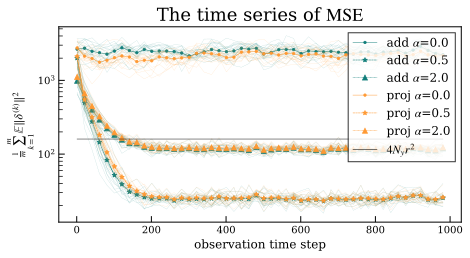

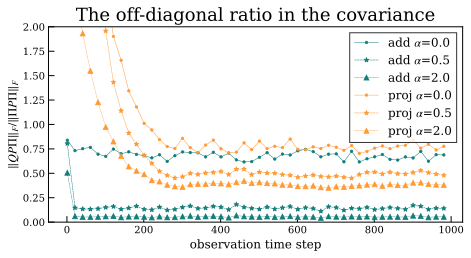

In [51]:
from visualize import get_color_palette, get_linestyle_cycle, get_marker_cycle

# obs noise impact dimension
Ny = np.linalg.matrix_rank(H)


# methods

# Plot
print(f"Visualize until {per_vis*N_end} steps")

lw = 0.5
# --------------

# load data
print("load file")
print(methods)
# xa_alpha = np.load(f"{data_dir}/xa_alpha-{paramname}.npy")
# evals_alpha = np.load(f"{data_dir}/evals_alpha-{method}-{paramname}.npy")

fig1, ax1 = plt.subplots(figsize=(7,4))
fig2, ax2 = plt.subplots(figsize=(7,4))

num_alpha = len(alpha_list)
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

time_ticks = np.arange(Nt//per_vis)*per_vis + 1
time_ticklabels = np.arange(Nt//per_ticklabel+1)*per_ticklabel
time_ticklabels[0] = 1

Nt = len(x_true)
for k, method in enumerate(methods):
    paramname = f"m({m})-{method}-alpha({'='.join([str(alpha) for alpha in alpha_list])})-seeds({len(seed_list)})"
    print(paramname)
    Xa = np.load(f"{data_dir}/xa-{paramname}.npy")

    color = colors[k]
    line_cycle = get_linestyle_cycle()
    marker_cycle = get_marker_cycle()

    for i, xa in enumerate(Xa):
        alpha = alpha_list[i]
        if i in [3, 4]:
            print("skip alpha:", alpha)
            continue

        # set plot vars
        ls = next(line_cycle)
        marker = next(marker_cycle)

        # compute SE stats
        se_wtm = loss_sq(x_true[None, :, None, :] - xa, 0) + loss_sq(x_true[None, :, None, :] @ H.T - xa @ H.T, 0) # (Nseed, Nt, m)
        se_tm, _ = stats(se_wtm) # (Nt, m); take the expectation E[]
        se_t = se_tm.mean(axis=1) # (Nt, ); take the ensemble mean
        se_wt = se_wtm.mean(axis=2) # (Nseed, Nt)
        print("t-averaged SE", se_tm[Nt//2:].mean()) # time average of SE after spin-up (100 obs. steps)


        # plot RMSE of analysis
        ax1.plot(time_ticks[:N_end], se_t[::per_vis][:N_end], label=f"{method.replace('po_', '')} $\\alpha$={alpha}", lw=lw, ls=ls, color=color, marker=marker, ms=5)
        for se_k in se_wt:
            ax1.plot(time_ticks[:N_end], se_k[::per_vis][:N_end], lw=lw/2, color=color, alpha=0.3)
            

        # plot ratio of symmetric/non-symetric part of cov.
        # compute RF = ||QPH^T||_F / ||HPH^T||_F
        Pi = H.T @ H
        Q = np.eye(J) - Pi
        # Sample covariance across seeds at each time step
        dX = xa - xa.mean(axis=2, keepdims=True)
        P = (dX.swapaxes(-2, -1) @ dX) / (m - 1)
        QPHt = Q @ P @ Pi.T
        HPHt = Pi @ P @ Pi.T
        rf = (np.linalg.norm(QPHt, axis=(2, 3)) / np.linalg.norm(HPHt, axis=(2, 3))).mean(axis=0) # FIXME: change to compute the ratio of operator norms
        ax2.plot(time_ticks[:N_end], rf[::per_vis][:N_end], label=f"{method.replace('po_', '')} $\\alpha$={alpha}", lw=lw, ls=ls, color=color, marker=marker, ms=5)
    

        # dev Kalman gain structure using (analysis cov.)
        # PPi = HPHt.mean(axis=0)[-1]
        # P_ = P.mean(axis=0)[-1]
        # K = P_ @ H.T @ np.linalg.inv(H @ P_ @ H.T + R)
        # plt.imshow(np.abs(K), interpolation='none', vmax=0.1, vmin=0.0)
        # plt.show()

        # KPi = PP @ H.T @ np.linalg.inv(H @ PP @ H.T + R)
        # plt.imshow(np.abs(KPi), interpolation='none', vmax=0.1, vmin=0.0)
        # plt.show()

# observation noise std
ax1.plot(time_ticks[:N_end], 4*Ny*(r**2)*np.ones_like(time_ticks[:N_end]), label='$ 4 N_y r^2 $', lw=lw, c="black")

ax1.set_xlabel("observation time step")
ax1.set_title("The time series of $\\mathrm{MSE}$")
ax1.set_ylabel(r"$ \frac{1}{m} \sum_{k=1}^m \mathbb{E} \|\delta^{(k)}\|^2 $")
ax1.set_yscale("log")
# ax1.set_ylim([r/100, 1])
fig1.tight_layout()
ax1.legend(bbox_to_anchor=(1.0, 1.0), loc='upper right')
fig1.tight_layout()

ax2.set_title("The off-diagonal ratio in the covariance")
ax2.set_ylabel(r"$\|QP\Pi\|_F / \|\Pi P \Pi\|_F$")
ax2.set_xlabel("observation time step")
ax2.set_ylim([0.0, 2.0])
ax2.legend(bbox_to_anchor=(1.0, 1.0), loc='upper right')
fig2.tight_layout()


# save fig
fig1.savefig(f"{data_dir}/l96-po-inflation_Pse.pdf", transparent=True)
fig2.savefig(f"{data_dir}/l96-po-inflation_offDiag.pdf", transparent=True)

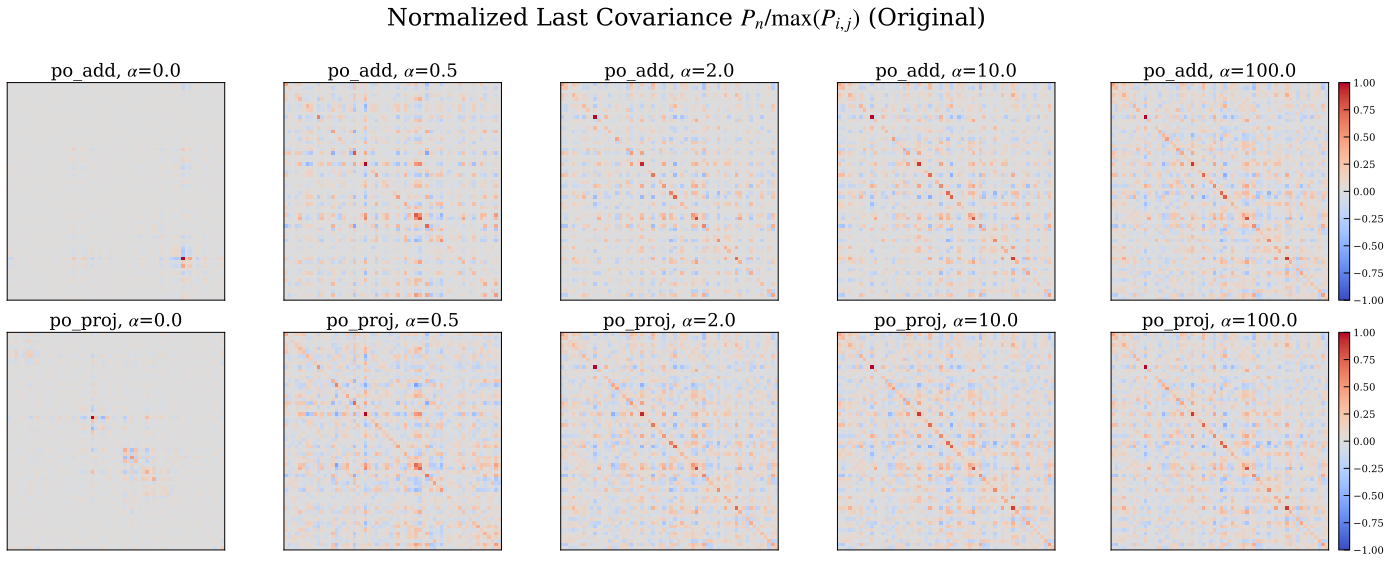

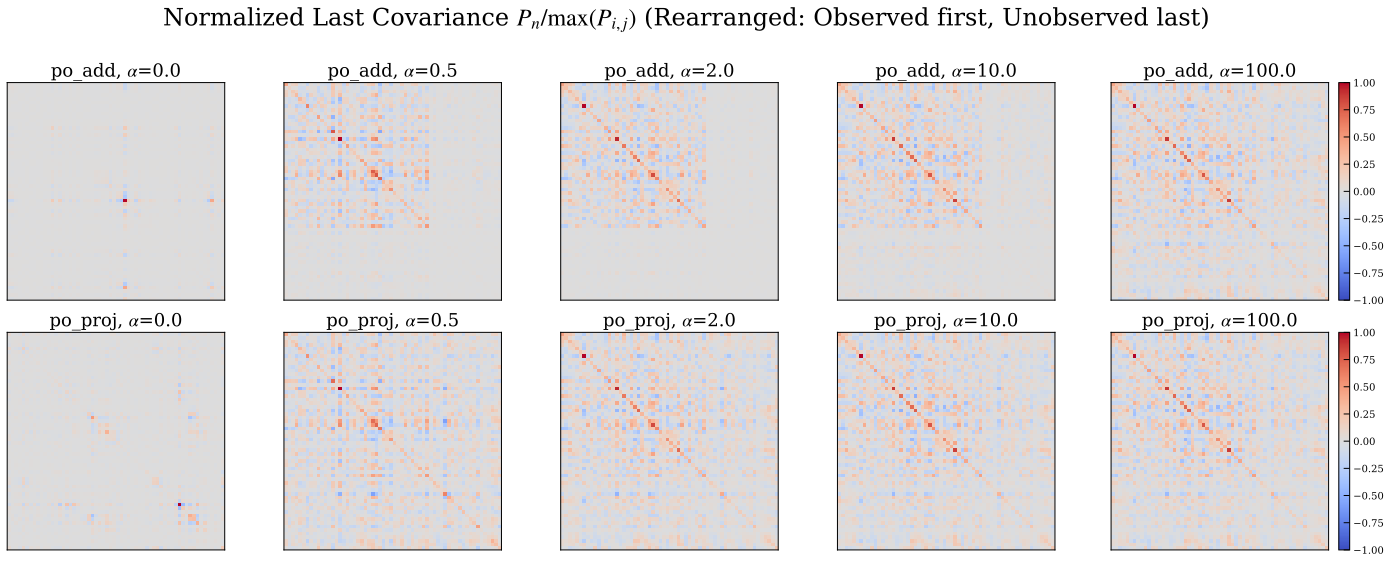

In [52]:
# plot last covariance for all (alpha, method)
num_methods = len(methods)
num_alphas = len(alpha_list)

# Compute sort index for rearranging P
observed_idx = np.where(np.diag(H.T @ H) > 0.5)[0]
unobserved_idx = np.where(np.diag(H.T @ H) <= 0.5)[0]
sort_idx = np.concatenate([observed_idx, unobserved_idx])
vmax = 1.0
vmin= -1.0

fig1, axes1 = plt.subplots(num_methods, num_alphas, figsize=(4 * num_alphas, 4 * num_methods))
fig2, axes2 = plt.subplots(num_methods, num_alphas, figsize=(4 * num_alphas, 4 * num_methods))

if num_methods == 1 and num_alphas == 1:
    axes1 = np.array([[axes1]])
    axes2 = np.array([[axes2]])
elif num_methods == 1:
    axes1 = axes1[np.newaxis, :]
    axes2 = axes2[np.newaxis, :]
elif num_alphas == 1:
    axes1 = axes1[:, np.newaxis]
    axes2 = axes2[:, np.newaxis]

for r, method in enumerate(methods):
    paramname = f"m({m})-{method}-alpha({'='.join([str(alpha) for alpha in alpha_list])})-seeds({len(seed_list)})"
    Xa = np.load(f"{data_dir}/xa-{paramname}.npy")
    for c, alpha in enumerate(alpha_list):
        xa = Xa[c, i_seed]
        dX = xa - xa.mean(axis=1, keepdims=True)
        P = (dX.swapaxes(-2, -1) @ dX) / (m - 1)
        P_last = P[-1]
        P_last /= P_last.max()
        
        # Original P
        ax1 = axes1[r, c]
        im1 = ax1.imshow(P_last, cmap="coolwarm", interpolation="none", vmax=vmax, vmin=vmin)
        ax1.set_title(f"{method}, $\\alpha$={alpha}")
        ax1.set_xticks([])
        ax1.set_yticks([])
        if c==len(alpha_list)-1:
            fig1.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
        
        # Rearranged P
        P_rearranged = P_last[sort_idx][:, sort_idx]
        ax2 = axes2[r, c]
        im2 = ax2.imshow(P_rearranged, cmap="coolwarm", interpolation="none", vmax=vmax, vmin=vmin)
        ax2.set_title(f"{method}, $\\alpha$={alpha}")
        ax2.set_xticks([])
        ax2.set_yticks([])
        if c==len(alpha_list)-1:
            fig2.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

fig1.suptitle("Normalized Last Covariance $P_n/\\max(P_{i,j})$ (Original)")
fig1.tight_layout()

fig2.suptitle("Normalized Last Covariance $P_n/\\max(P_{i,j})$ (Rearranged: Observed first, Unobserved last)")
fig2.tight_layout()
plt.show()

# save fig
fig2.savefig(f"{data_dir}/normalized_last_covariance")

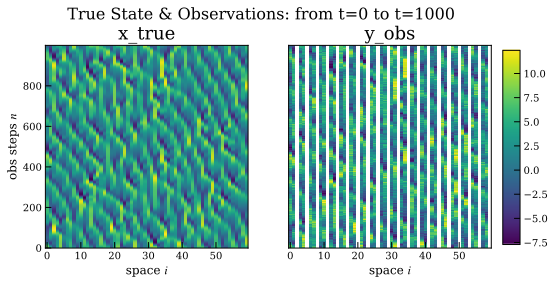

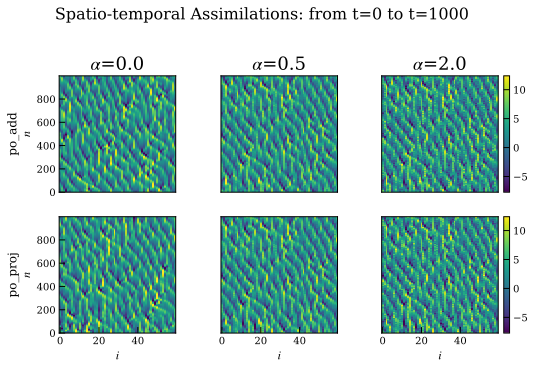

In [ ]:
# Spatio-temporal Plot
# TODO: change to one global color bar with independent ax

# load data
x_true = np.load(f"{data_dir}/x_true_l96_full.npy")
Y = np.load(f"{data_dir}/y-seeds({num_seeds}).npy")
y = Y[i_seed]

num_methods = len(methods)
num_alphas = len(alpha_list_vis_st)

x1 = x_true[n_start:n_end]
y_extend = (H.T@y[n_start:n_end].T).T # embed y into state space: (T, Ny) -> (T, Nx)
y_mask = np.ma.masked_where(y_extend==0.0, y_extend)
x2 = y_mask

vmax = np.max(x1)
vmin = np.min(x1)

# Figure 1: True state and Observations
fig1, ax1 = plt.subplots(1, 2, figsize=(4*2, 4))
im1 = ax1[0].imshow(x1, aspect=J/(n_end-n_start), vmax=vmax, vmin=vmin, origin="lower", interpolation="none")
ax1[0].set_ylabel("obs steps $n$")
ax1[0].set_xlabel("space $i$")
ax1[0].set_title("x_true")

ax1[1].imshow(x2, aspect=J/(n_end-n_start), vmax=vmax, vmin=vmin, origin="lower", interpolation="none")
ax1[1].set_xlabel("space $i$")
ax1[1].set_title("y_obs")
ax1[1].set_yticks([])

cax1 = fig1.add_axes([0.92, 0.155, 0.03, 0.675])
fig1.colorbar(im1, cax=cax1)
fig1.suptitle(f"True State & Observations: from t={n_start} to t={n_end}", fontsize=16)
fig1.savefig(f"{data_dir}/spatio_temporal_true_obs")
plt.show()

# Figure 2: Assimilated States
fig2, axes2 = plt.subplots(num_methods, num_alphas, figsize=(8, 8*num_methods/num_alphas))
if num_methods == 1 and num_alphas == 1:
    axes2 = np.array([[axes2]])
elif num_methods == 1:
    axes2 = axes2[np.newaxis, :]
elif num_alphas == 1:
    axes2 = axes2[:, np.newaxis]

for r_idx, m_name in enumerate(methods):
    paramname = f"m({m})-{m_name}-alpha({'='.join([str(alpha) for alpha in alpha_list])})-seeds({len(seed_list)})"
    Xa = np.load(f"{data_dir}/xa-{paramname}.npy")
    for a_idx, alpha_val in enumerate(alpha_list_vis_st):
        x_assim = Xa[a_idx, i_seed, :, k_ens]
        x3 = x_assim[n_start:n_end]

        ax = axes2[r_idx, a_idx]
        im2 = ax.imshow(x3, aspect=J/(n_end-n_start), vmax=vmax, vmin=vmin, origin="lower", interpolation="none")
        # ax.set_xticks([])
        # ax.set_yticks([])
        if r_idx == 0:
            ax.set_title(f"$\\alpha$={alpha_val}")
            ax.set_xticks([])
        elif r_idx == num_methods - 1:
            ax.set_xlabel("$i$")
        if a_idx == 0:
            ax.set_ylabel(m_name + "\n" + "$n$")
        else:
            ax.set_yticks([])
        if a_idx == num_alphas - 1:
            fig2.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)

fig2.suptitle(f"Spatio-temporal Assimilations: from t={n_start} to t={n_end}", fontsize=16)
fig2.tight_layout()
fig2.savefig(f"{data_dir}/spatio_temporal_assimilations")
plt.show()


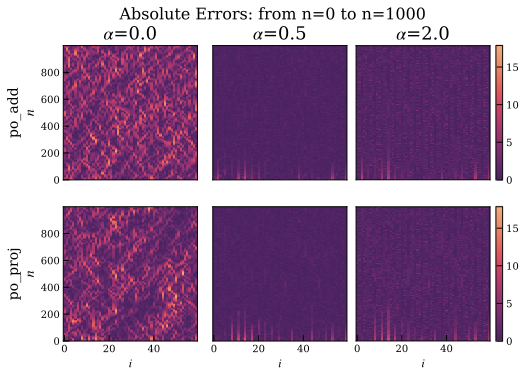

In [ ]:
# Spatio-temporal Plot: Absolute Errors
# TODO: change to one global color bar with independent ax

# load data
x_true = np.load(f"{data_dir}/x_true_l96_full.npy")
x_t = x_true[n_start:n_end]

num_methods = len(methods)
num_alphas = len(alpha_list_vis_st)

# Pass 1: compute global maximum absolute error for consistent vmax
global_vmax = 0.0
for m_name in methods:
    paramname = f"m({m})-{m_name}-alpha({'='.join([str(alpha) for alpha in alpha_list])})-seeds({len(seed_list)})"
    Xa = np.load(f"{data_dir}/xa-{paramname}.npy")
    for a_idx in range(num_alphas):
        x_assim = Xa[a_idx, i_seed].mean(axis=1)
        e_assim = np.abs(x_assim[n_start:n_end] - x_t)
        global_vmax = max(global_vmax, np.max(e_assim))

vmin = 0.0
vmax = max(0.0, global_vmax)  # ensure vmax >= vmin

fig, axes = plt.subplots(num_methods, num_alphas, figsize=(8, 8*num_methods/num_alphas))
if num_methods == 1 and num_alphas == 1:
    axes = np.array([[axes]])
elif num_methods == 1:
    axes = axes[np.newaxis, :]
elif num_alphas == 1:
    axes = axes[:, np.newaxis]

for r_idx, m_name in enumerate(methods):
    paramname = f"m({m})-{m_name}-alpha({'='.join([str(alpha) for alpha in alpha_list])})-seeds({len(seed_list)})"
    Xa = np.load(f"{data_dir}/xa-{paramname}.npy")
    for a_idx, alpha_val in enumerate(alpha_list_vis_st):
        x_assim = Xa[a_idx, i_seed, :, k_ens]
        e_assim = np.abs(x_assim[n_start:n_end] - x_t)

        ax = axes[r_idx, a_idx]
        im = ax.imshow(e_assim, aspect=J/(n_end-n_start), vmax=vmax, vmin=vmin, origin="lower", interpolation="none", cmap="flare_r")
        if r_idx == 0:
            ax.set_title(f"$\\alpha$={alpha_val}")
            ax.set_xticks([])
        elif r_idx == num_methods - 1:
            ax.set_xlabel("$i$")
        if a_idx == 0:
            ax.set_ylabel(m_name + "\n" + "$n$", fontsize=14)
        else:
            ax.set_yticks([])
        if a_idx == num_alphas - 1:
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.subplots_adjust(wspace=0.02, hspace=0.2)

fig.suptitle(f"Absolute Errors: from n={n_start} to n={n_end}", fontsize=16)
# fig.tight_layout()
fig.savefig(f"{data_dir}/absolute_errors_all")
plt.show()
